1. Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

2. Load Dataset

In [48]:
df = pd.read_csv("sales.csv", encoding='latin1')

In [49]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


3. Basic Info

In [50]:
print(df.shape)

(9994, 21)


In [51]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

4. Data Cleaning

In [53]:
df.columns = df.columns.str.strip()

# Convert Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Sort data
df = df.sort_values('Order Date')

In [54]:
# Check missing values
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [55]:
# Fill missing values
df.ffill(inplace=True)

In [56]:
df_daily = df.groupby('Order Date')['Sales'].sum().reset_index()

df_daily.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


5. Feature Engineering

In [57]:
df_daily['year'] = df_daily['Order Date'].dt.year
df_daily['month'] = df_daily['Order Date'].dt.month
df_daily['day'] = df_daily['Order Date'].dt.day
df_daily['dayofweek'] = df_daily['Order Date'].dt.dayofweek

6. Visualization

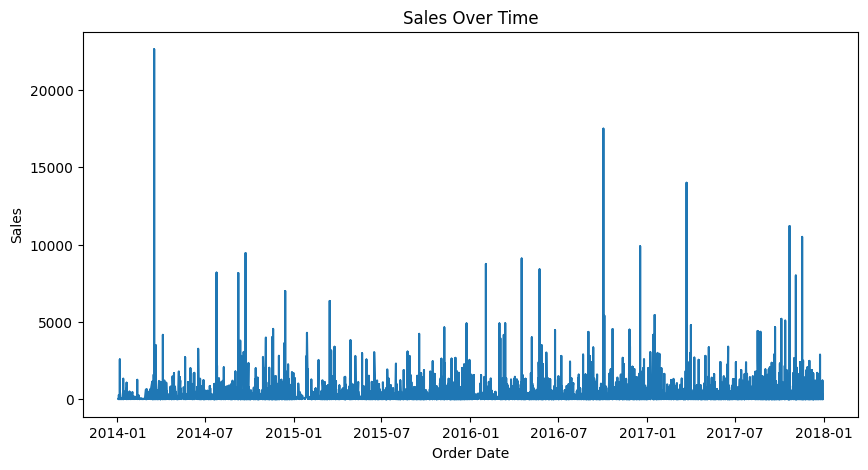

In [58]:
plt.figure(figsize=(10,5))
plt.plot(df['Order Date'], df['Sales'])
plt.title("Sales Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.show()

7. Train-Test Split

In [59]:
from sklearn.model_selection import train_test_split

X = df_daily[['year','month','day','dayofweek']]
y = df_daily['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

8. Model Training

In [60]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


9. Model Evaluation

In [61]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 1798.6441061935486
RMSE: 2527.505671086113


10. Forecast Future Sales

In [62]:
future_dates = pd.date_range(start=df['Order Date'].max(), periods=30)

future_df = pd.DataFrame({'Order Date': future_dates})

future_df['year'] = future_df['Order Date'].dt.year
future_df['month'] = future_df['Order Date'].dt.month
future_df['day'] = future_df['Order Date'].dt.day
future_df['dayofweek'] = future_df['Order Date'].dt.dayofweek

future_predictions = model.predict(future_df[['year','month','day','dayofweek']])

future_df['Predicted_Sales'] = future_predictions

future_df.head()

,Order Date,year,month,day,dayofweek,Predicted_Sales
0,2017-12-30,2017,12,30,5,1961.580702
1,2017-12-31,2017,12,31,6,3208.088118
2,2018-01-01,2018,1,1,0,2091.760360
3,2018-01-02,2018,1,2,1,3912.386760
4,2018-01-03,2018,1,3,2,1728.775400


In [63]:
df_daily['lag1'] = df_daily['Sales'].shift(1)
df_daily.dropna(inplace=True)

X = df_daily[['year','month','day','dayofweek','lag1']]
y = df_daily['Sales']

Text(0, 0.5, 'Sales')

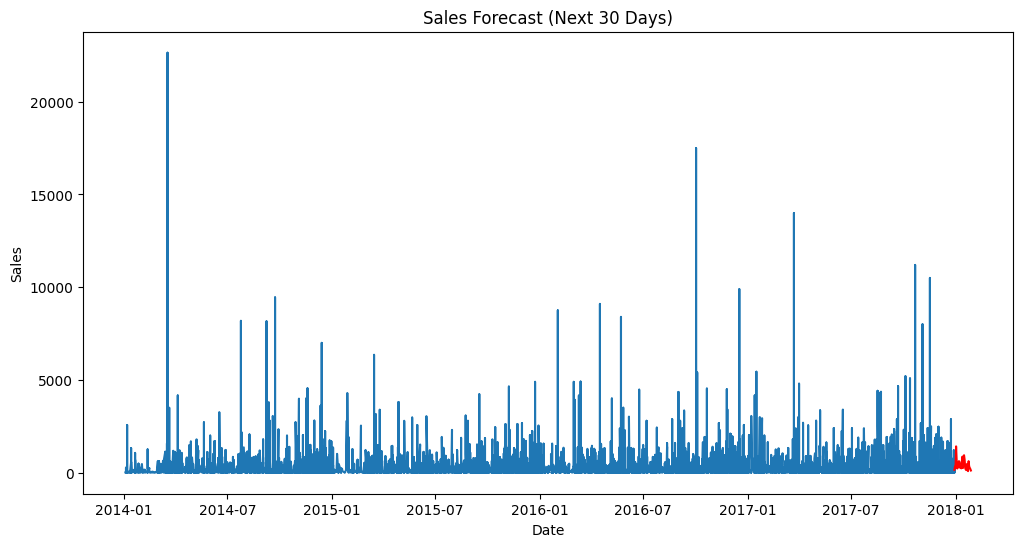

In [42]:
plt.figure(figsize=(12,6))

# Actual sales
plt.plot(df['Order Date'], df['Sales'], label='Actual Sales')

# Forecast
plt.plot(future_df['Order Date'], future_df['Predicted_Sales'], label='Forecast', color='red')

plt.title("Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")

Forecast Meaning:

The model predicts future sales based on historical patterns such as seasonality and trends.

Insights:
- Sales show consistent growth over time
- Certain periods (e.g., month-end/weekends) have higher demand

Business Use:
- Helps in inventory planning (avoid stockouts)
- Supports staffing decisions during peak periods
- Helps marketing team plan promotions